In [2]:
pip install gpstime

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
import numpy as np

O3a observation segments from GWOSC V

cut the triggers using the GWOSC intervals V

apply 1D clustering with cutoff triggers and remove duplicate data V

apply 2D clustering V

# O3a observation segments from GWOSC

In [2]:
date_start = "2019-04-01 01:00"
date_end = "2019-04-10 15:00"

gps_start = Time(date_start, scale="utc").gps
gps_end = Time(date_end, scale="utc").gps

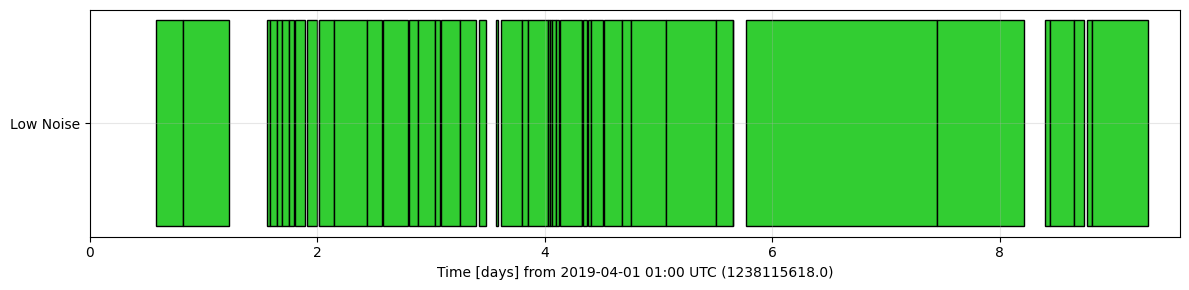

In [3]:
basedata = os.getcwd()
intervals = pd.read_csv(basedata + '/zrepository/gwoscO3atxt.txt', sep=' ', header=None, names=['int1', 'int2', 'duration'])

df = intervals[(intervals['int1'] >= gps_start) & (intervals['int2'] <= gps_end)]

begin_days = (df['int1'] - gps_start) / 86400
duration_days = df['duration'] / 86400

plt.figure(figsize=(12, 3))
plt.barh(y=0, width=duration_days, left=begin_days, height=0.5, color='limegreen', edgecolor='black')

plt.yticks([0], ['Low Noise'])
plt.xlabel(f'Time [days] from {date_start} UTC ({gps_start})')
plt.xlim(0, (gps_end - gps_start) / 86400)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cut the triggers using the GWOSC intervals

In [4]:
intervals_crop = intervals[(intervals['int2'] >= gps_start) & (intervals['int1'] <= gps_end)].sort_values('int1')
intervals_crop['int1'] = intervals_crop['int1'].astype('float64')

total_triggers_winddow = 0
filtered_chunks = []

for chunk in pd.read_csv(basedata + '/triggers_total.csv', chunksize=10000000):

    chunk['time'] = chunk['time'].astype('float64')
    
    chunk = chunk[(chunk['time'] >= gps_start) & (chunk['time'] <= gps_end)].sort_values('time')
    if chunk.empty:
        continue

    total_triggers_winddow += len(chunk)
    
    merged = pd.merge_asof(chunk, intervals_crop, left_on='time', right_on='int1', direction='backward')
    valid = merged[(merged['time'] >= merged['int1']) & (merged['time'] <= merged['int2'])]
    
    filtered_chunks.append(valid[['time', 'frequency', 'snr']])

triggers_crop = pd.concat(filtered_chunks, ignore_index=True)

int_s_days = (intervals_crop['int1'] - gps_start) / 86400
int_e_days = (intervals_crop['int2'] - gps_start) / 86400
trig_days  = (triggers_crop['time'] - gps_start) / 86400

/tmp/ipykernel_168020/380753242.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/esanches/Projetos/tSNE/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


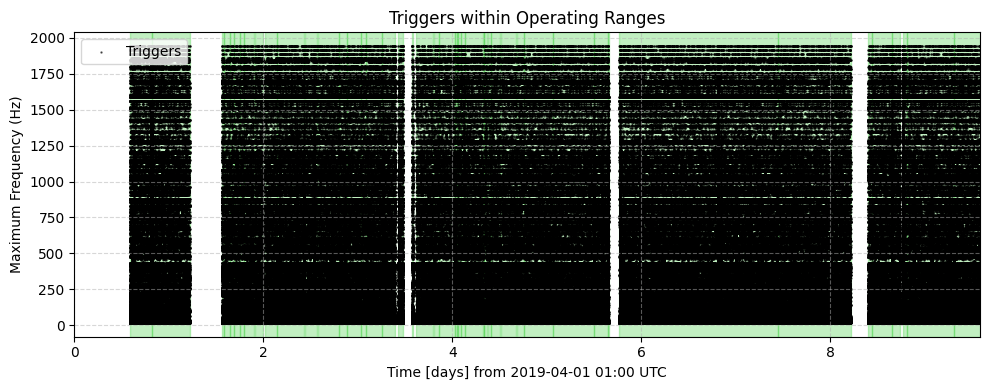

In [5]:
plt.figure(figsize=(10, 4))

for s, e in zip(int_s_days, int_e_days):
    plt.axvspan(s, e, color='limegreen', alpha=0.3)

plt.scatter(trig_days, triggers_crop['frequency'], c='black', s=0.5, alpha=0.6, label='Triggers')

plt.xlabel(f'Time [days] from {date_start} UTC')
plt.ylabel('Maximum Frequency (Hz)')
plt.title('Triggers within Operating Ranges')
plt.xlim(0, (gps_end - gps_start) / 86400)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

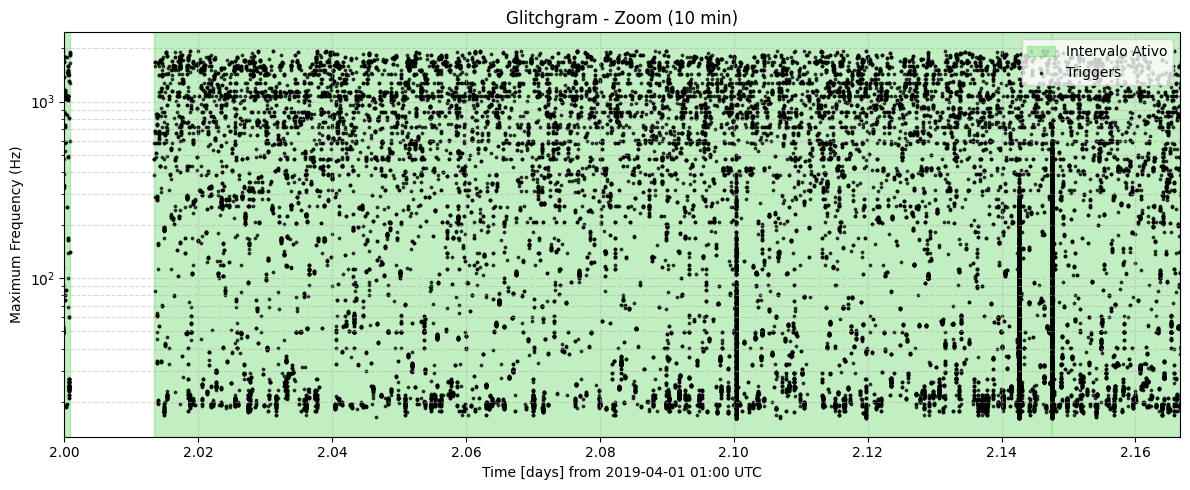

In [6]:
import matplotlib.pyplot as plt

# 1. Garante que os intervalos peguem TODO o período (baseado no gps_start e gps_end)
intervals_plot = intervals[(intervals['int2'] >= gps_start) & (intervals['int1'] <= gps_end)].copy()

# Recalcula o tempo em dias para garantir que usam exatamente a mesma referência de tempo (gps_start)
int_s_days = (intervals_plot['int1'] - gps_start) / 86400
int_e_days = (intervals_plot['int2'] - gps_start) / 86400

# 2. Configurações do Zoom (exemplo: zoom de 10 minutos)
minutos_de_zoom = 10
zoom_start_dia = 2.0  # Começo do zoom em dias
zoom_end_dia = zoom_start_dia + (minutos_de_zoom / 60)

# 3. Plotagem
plt.figure(figsize=(12, 5))

# Plota os intervalos ativos cobrindo toda a extensão do gráfico
for i, (s, e) in enumerate(zip(int_s_days, int_e_days)):
    plt.axvspan(s, e, color='limegreen', alpha=0.3, label='Intervalo Ativo' if i == 0 else "")

# Plota os triggers
plt.scatter(
    trig_days, 
    triggers_crop['frequency'], 
    c='black', 
    s=3, 
    alpha=0.7, 
    label='Triggers'
)

plt.yscale('log')
plt.xlabel(f'Time [days] from {date_start} UTC')
plt.ylabel('Maximum Frequency (Hz)')
plt.title(f'Glitchgram - Zoom ({minutos_de_zoom} min)')

# Limita o eixo X para a janela desejada
plt.xlim(zoom_start_dia, zoom_end_dia)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [7]:
total_triggers_winddow

4437242

In [8]:
len(trig_days)

3638631

# Apply full 2D clustering

In [22]:
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

## Glitches clustering

In [29]:
def clusterize_triggers1D(gltab, window, min_triggers):
    
    if len(gltab) == 0:
        return pd.DataFrame()

    table = gltab.copy()
    table = table.sort_values(by='time').reset_index(drop=True)

    times = table['time'].values
    deltas = times[1:] - times[:-1]

    new_cluster_mask = np.concatenate([[False], deltas > window])
    cluster_ids = np.cumsum(new_cluster_mask)

    table['cluster'] = cluster_ids

    # filter: Retains only clusters with "min_triggers" or more triggers
    counts = table['cluster'].value_counts()
    valid_clusters = counts[counts >= min_triggers].index
    
    table_filtered = table[table['cluster'].isin(valid_clusters)]

    if table_filtered.empty:
        return pd.DataFrame()
    
    # groups by cluster and extracts the representative (row with the highest SNR) + extremes
    summary_rows = []

    print(table_filtered)
    
    for cl, group in table_filtered.groupby('cluster'):
        # Encontra o trigger com maior SNR dentro deste grupo
        max_row = group.loc[group['snr'].idxmax()]

        summary_rows.append({
            'cluster': cl,
            'num_triggers': len(group), # quantidade de triggers no cluster
            'tstart': group['time'].min(),
            'tend': group['time'].max(),
            'time': max_row['time'],
            'frequency': max_row['frequency'],
            'min_freq': group['frequency'].min(),
            'max_freq': group['frequency'].max(),
            'snr': max_row['snr']
        })

    return pd.DataFrame(summary_rows)

In [42]:
def clusterize_triggers2D(gltab, window_T, window_F, min_triggers):

    if len(gltab) == 0:
        return pd.DataFrame()

    table = gltab.copy()

    times = table['time'].values
    freqs = table['frequency'].values
    n = len(times)

    # Ordena por tempo para facilitar a janela deslizante
    sort_idx = np.argsort(times)
    times_sorted = times[sort_idx]
    freqs_sorted = freqs[sort_idx]
    
    connections = []

    # Para cada trigger, olha APENAS para os próximos que estão dentro da janela de tempo
    for i in range(n):
        t_curr = times_sorted[i]
        f_curr = freqs_sorted[i]

        # Busca apenas os candidatos dentro da janela de tempo t_curr + window_T
        for j in range(i + 1, n):
            if times_sorted[j] - t_curr > window_T:
                break  # Como está ordenado, se estourou o tempo, para a busca imediatamente!

            # Testa a condição de frequência
            if abs(freqs_sorted[j] - f_curr) <= window_F:
                # Conecta o trigger i ao trigger j
                connections.append((sort_idx[i], sort_idx[j]))
    
    # Monta os grupos com base nas conexões encontradas
    if connections:
        pairs = np.array(connections)
        data = np.ones(len(pairs), dtype=bool)
        adj = csr_matrix((data, (pairs[:, 0], pairs[:, 1])), shape=(n, n))
        _, cluster_ids = connected_components(csgraph=adj, directed=False)
    else:
        cluster_ids = np.arange(n)

    table['cluster'] = cluster_ids

    # filter: Retains only clusters with "min_triggers" or more triggers
    counts = table['cluster'].value_counts()
    valid_clusters = counts[counts >= min_triggers].index
    
    table_filtered = table[table['cluster'].isin(valid_clusters)]

    if table_filtered.empty:
        return pd.DataFrame()
    
    # groups by cluster and extracts the representative (row with the highest SNR) + extremes
    summary_rows = []

    print(table_filtered)
    
    for cl, group in table_filtered.groupby('cluster'):
        # Encontra o trigger com maior SNR dentro deste grupo
        max_row = group.loc[group['snr'].idxmax()]

        summary_rows.append({
            'cluster': cl,
            'num_triggers': len(group), # quantidade de triggers no cluster
            'tstart': group['time'].min(),
            'tend': group['time'].max(),
            'time': max_row['time'],
            'frequency': max_row['frequency'],
            'min_freq': group['frequency'].min(),
            'max_freq': group['frequency'].max(),
            'snr': max_row['snr']
        })

    return pd.DataFrame(summary_rows)

In [66]:
run_start_day_O3a = datetime(2019, 4, 1, 1, 0, 0)
run_end_day_O3a   = datetime(2019, 10, 1, 23, 59, 59)

run_start_day_O3b = datetime(2019, 11, 1, 0, 0, 0)
run_end_day_O3b   = datetime(2020, 3, 27, 23, 59, 59)

run_end_day_test = datetime(2019, 4, 10, 15, 0, 0)

In [67]:
current_day = run_start_day_O3a

snr_thresholds = [6.5, 10]         # corte de SNR
window_T, window_F = 0.1, 20       # janela de clusterização (segundos)
min_triggers = 20                   # triggers mínimos por glitch

In [68]:
triggers_crop.tail()

,time,frequency,snr
3638626,1.238944e+09,314.765637,5.167286
3638627,1.238944e+09,67.564225,5.202656
3638628,1.238944e+09,67.570013,5.263788
3638629,1.238944e+09,66.593124,5.058040
3638630,1.238944e+09,67.564225,5.225475


In [69]:
trigger_count = []
glitch_count = []

clustered_list = []

global_cluster_ID = 0

while current_day <= run_end_day_test:
    
    # declare the start and end of the current day
    day_start = datetime(current_day.year, current_day.month, current_day.day, 0, 0, 0)
    day_end   = datetime(current_day.year, current_day.month, current_day.day, 23, 59, 59)

    print(f"Processing day: {current_day.date()}")

    # convert the time to gpsTIME
    gps_start = Time(day_start, scale="utc").gps
    gps_end   = Time(day_end, scale="utc").gps

    # limit the intervals to the current day only
    day_interval = intervals[(intervals['int2'] >= gps_start) & (intervals['int1'] <= gps_end)].copy()

    # cut intervals before gps_start and after gps_end
    day_interval['start_recortado'] = day_interval['int1'].clip(lower=gps_start)
    day_interval['end_recortado']   = day_interval['int2'].clip(upper=gps_end)

    # duration of the intervals of the current day
    day_duration_sec = (day_interval['end_recortado'] - day_interval['start_recortado']).sum()
    day_duration_hrs = day_duration_sec / 3600

    print(f'Opening hours for this day: {day_duration_hrs:.2f}')

    # triggers of the current day
    trigfiles = triggers_crop[(triggers_crop['time'] >= gps_start) & (triggers_crop['time'] <= gps_end)]
    gltab = trigfiles.copy()

    trigger_count.append(len(gltab))
    print(f'Triggers count for this day: {len(gltab)}\n')

    # CLUSTERING OF THE CURRENT DAY
    if not gltab.empty:
        gltab = gltab.sort_values(by="time").drop_duplicates(subset=["time"]).reset_index(drop=True)

        # the MAIN FUNCTION of this clustering process
        # clustered = clusterize_triggers1D(gltab, window_T, min_triggers)
        clustered = clusterize_triggers2D(gltab, window_T, window_F, min_triggers)

        glitch_count.append(len(clustered))
        print(f'\nGlitches count for this day: {len(clustered)}\n')
        
        # adds the day's result to the list if there are glitches
        if not clustered.empty:
            
            # adjusts the day's IDs by adding the accumulated ID
            clustered['cluster'] += global_cluster_ID

            # update the ID for the next day to avoid repeating numbers
            global_cluster_ID = clustered['cluster'].max() + 1
            
            clustered_list.append(clustered)
            
    current_day += timedelta(days=1)

# appends to the FINAL DataFrame every day
if clustered_list:
    df_glitches_final = pd.concat(clustered_list, ignore_index=True)
else:
    df_glitches_final = pd.DataFrame()

Processing day: 2019-04-01
Opening hours for this day: 9.00
Triggers count for this day: 212320

               time  frequency       snr  cluster
354    1.238166e+09  24.171913  5.004943      154
355    1.238166e+09  23.091503  5.459014      154
356    1.238166e+09  24.432328  5.583851      154
357    1.238166e+09  24.171913  6.309030      154
358    1.238166e+09  24.432328  6.250550      154
...             ...        ...       ...      ...
57185  1.238198e+09  19.816910  6.428682    17636
57186  1.238198e+09  19.494597  6.003921    17636
57187  1.238198e+09  18.424750  5.344046    17636
57188  1.238198e+09  18.717953  5.287531    17636
57189  1.238198e+09  19.453599  5.835186    17636

[19084 rows x 4 columns]

Glitches count for this day: 104

Processing day: 2019-04-02
Opening hours for this day: 15.39
Triggers count for this day: 172113

               time   frequency       snr  cluster
58     1.238199e+09  700.865993  5.519563       39
59     1.238199e+09  668.913765  5.280042 

In [82]:
df_glitches_final

,cluster,num_triggers,tstart,tend,time,frequency,min_freq,max_freq,snr
0,154,41,1.238166e+09,1.238166e+09,1.238166e+09,24.171913,18.819545,26.742411,7.198181
1,295,20,1.238167e+09,1.238167e+09,1.238167e+09,215.134078,203.446300,226.695319,6.404389
2,378,28,1.238167e+09,1.238167e+09,1.238167e+09,19.453599,17.731117,21.775510,8.515493
3,586,28,1.238167e+09,1.238167e+09,1.238167e+09,23.091503,17.731117,26.742411,8.126851
4,638,20,1.238167e+09,1.238167e+09,1.238167e+09,25.986516,23.091503,27.352067,7.263309
...,...,...,...,...,...,...,...,...,...
8576,407540,23,1.238942e+09,1.238942e+09,1.238942e+09,208.700195,208.700195,226.695319,24.151369
8577,407811,42,1.238942e+09,1.238942e+09,1.238942e+09,25.613012,24.432328,49.533298,8.632145
8578,408146,29,1.238943e+09,1.238943e+09,1.238943e+09,24.196774,16.889483,29.012166,6.880057
8579,408156,135,1.238943e+09,1.238943e+09,1.238943e+09,26.358692,21.775510,60.831633,11.690671


## Glitches visualization

In [72]:
run_start_day_O3a = datetime(2019, 4, 1, 15, 0, 0)

# 1. Definir os limites de tempo (GPS) estritamente para os 10 dias de teste
start = Time(run_start_day_O3a, scale="utc").gps
end = Time(run_end_day_test, scale="utc").gps

intervals_crop = intervals[(intervals['int2'] >= start) & (intervals['int1'] <= end)].copy()
glitches_crop = df_glitches_final[(df_glitches_final['time'] >= start) & (df_glitches_final['time'] <= end)].copy()

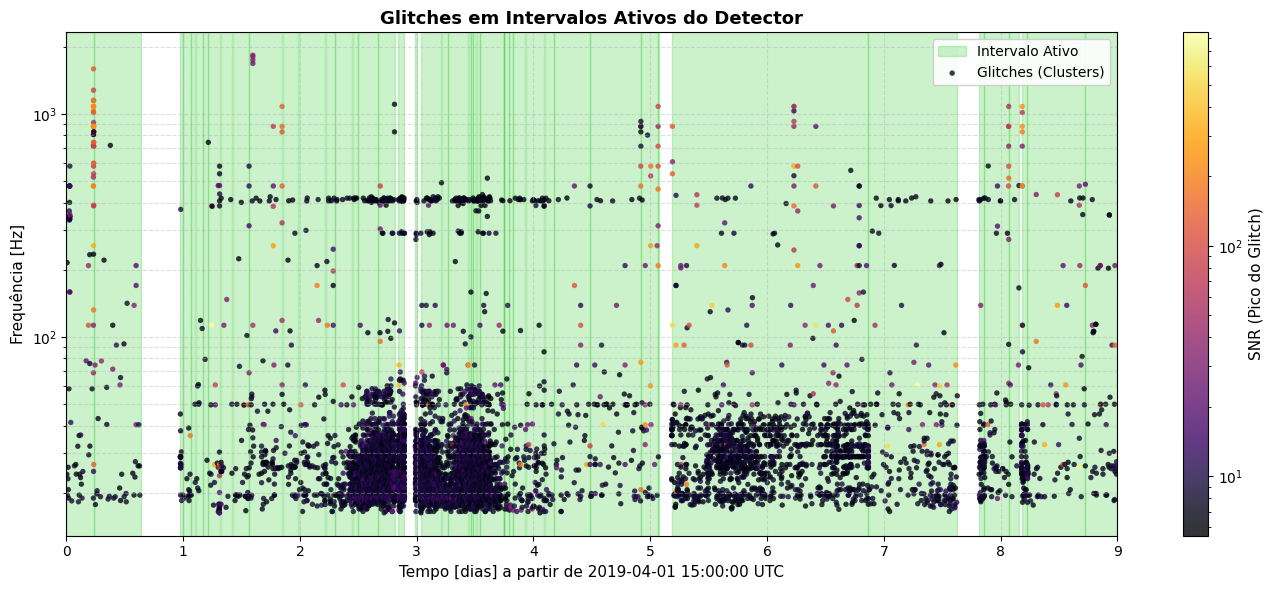

In [73]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 2. Converte os tempos para "dias a partir de 'start'"
intervals_start_days = (intervals_crop['int1'] - start) / 86400
intervals_end_days = (intervals_crop['int2'] - start) / 86400
glitches_days = (glitches_crop['time'] - start) / 86400

# 3. Cria a figura
plt.figure(figsize=(14, 6))

# Plota os intervalos de funcionamento (lock-in) em verde
for i, (s, e) in enumerate(zip(intervals_start_days, intervals_end_days)):
    plt.axvspan(s, e, color='limegreen', alpha=0.25, label='Intervalo Ativo' if i == 0 else "")

# Plota os Glitches
scatter = plt.scatter(
    glitches_days, 
    glitches_crop['frequency'], 
    c=glitches_crop['snr'],         # Cor baseada na SNR do pico
    norm=LogNorm(vmin=glitches_crop['snr'].min(), vmax=glitches_crop['snr'].max()), # Escala Log na cor
    cmap='inferno', 
    s=15,                           # Tamanho do marcador
    alpha=0.8, 
    edgecolors='none',
    label='Glitches (Clusters)'
)

# Configurações do Gráfico
plt.yscale('log')  # Escala logarítmica obrigatória para frequência de interferômetros
cbar = plt.colorbar(scatter)
cbar.set_label('SNR (Pico do Glitch)', fontsize=11)

plt.xlabel(f'Tempo [dias] a partir de {run_start_day_O3a} UTC', fontsize=11)
plt.ylabel('Frequência [Hz]', fontsize=11)
plt.title('Glitches em Intervalos Ativos do Detector', fontsize=13, fontweight='bold')

plt.xlim(0, (end - start) / 86400)
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

## GSPY clustering

In [74]:
path = os.getcwd()
path

'/home/esanches/Projetos/tSNE/Virgo'

In [96]:
df_O3a = pd.read_csv(path + '/gspyO3a.csv')
df_O3a = df_O3a[['GPStime', 'snr', 'centralFreq', 'confidence', 'label']]
df_O3a

,GPStime,snr,centralFreq,confidence,label
0,1.239157e+09,19989.938,3983.241,1.000,Extremely_Loud
1,1.239923e+09,10047.964,3983.241,1.000,Extremely_Loud
2,1.239912e+09,7198.535,3983.241,1.000,Extremely_Loud
3,1.243488e+09,6134.880,3983.241,1.000,Extremely_Loud
4,1.251572e+09,6099.467,3983.241,1.000,Extremely_Loud
...,...,...,...,...,...
80393,1.253167e+09,7.905,3680.246,0.187,Light_Modulation
80394,1.253478e+09,7.959,42.988,0.184,None_of_the_Above
80395,1.244633e+09,8.968,302.104,0.177,None_of_the_Above
80396,1.240533e+09,10.334,109.385,0.172,Scratchy


In [97]:
run_start_day_O3a = datetime(2019, 4, 1, 1, 0, 0)
run_end_day_test = datetime(2019, 4, 10, 15, 0, 0)

In [98]:
start = Time(run_start_day_O3a, scale="utc").gps
end = Time(run_end_day_test, scale="utc").gps

In [99]:
df_O3a = df_O3a[(df_O3a['GPStime'] >= start) & (df_O3a['GPStime'] <= end)]
df_O3a = df_O3a.sort_values(by=['GPStime']).reset_index(drop=True)
df_O3a

,GPStime,snr,centralFreq,confidence,label
0,1.238166e+09,12.088,211.877,1.000,Blip
1,1.238167e+09,7.867,20.195,0.998,Low_Frequency_Lines
2,1.238167e+09,8.180,65.530,1.000,Blip
3,1.238167e+09,8.306,19.370,0.965,Low_Frequency_Lines
4,1.238168e+09,12.113,357.194,1.000,Whistle
...,...,...,...,...,...
8279,1.238942e+09,9.956,63.212,0.414,Violin_Mode
8280,1.238942e+09,20.221,974.707,0.330,None_of_the_Above
8281,1.238942e+09,418.494,2964.093,1.000,Extremely_Loud
8282,1.238943e+09,14.842,2511.787,1.000,Scattered_Light


In [100]:
error = 100 * np.abs(len(df_O3a) - len(df_glitches_final)) / len(df_O3a)
print(f'error ~ {error:.2f} %')

error ~ 3.59 %


# Virgo clustering

In [103]:
df_O3a_virgo = pd.read_csv(path + '/gvirgo.csv')

df_O3a_virgo = df_O3a_virgo[['time', 'snr', 'frequency']]
df_O3a_virgo = df_O3a_virgo[(df_O3a_virgo['time'] >= start) & (df_O3a_virgo['time'] <= end)]
df_O3a_virgo = df_O3a_virgo.sort_values(by=['time']).reset_index(drop=True)
df_O3a_virgo

,time,snr,frequency
0,1.238165e+09,5.009650,1421.921349
1,1.238165e+09,5.133190,1013.443826
2,1.238165e+09,5.281003,396.149524
3,1.238165e+09,5.402536,406.775734
4,1.238165e+09,5.901958,1079.892919
...,...,...,...
324946,1.238944e+09,5.019192,82.744754
324947,1.238944e+09,5.379299,412.707577
324948,1.238944e+09,5.754347,21.775510
324949,1.238944e+09,5.167286,314.765637


In [104]:
error = 100 * np.abs(len(df_O3a_virgo) - len(df_glitches_final)) / len(df_O3a_virgo)
print(f'error ~ {error:.2f} %')

error ~ 97.36 %


In [56]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

def cluster_window_manual(times, freqs, window_T=0.5, window_F=20.0):
    n = len(times)
    connections = []

    # Ordena por tempo para facilitar a janela deslizante
    sort_idx = np.argsort(times)
    times_sorted = times[sort_idx]
    freqs_sorted = freqs[sort_idx]

    # Para cada trigger, olha APENAS para os próximos que estão dentro da janela de tempo
    for i in range(n):
        t_curr = times_sorted[i]
        f_curr = freqs_sorted[i]

        # Busca apenas os candidatos dentro da janela de tempo t_curr + window_T
        for j in range(i + 1, n):
            if times_sorted[j] - t_curr > window_T:
                break  # Como está ordenado, se estourou o tempo, para a busca imediatamente!

            # Testa a condição de frequência
            if abs(freqs_sorted[j] - f_curr) <= window_F:
                # Conecta o trigger i ao trigger j
                connections.append((sort_idx[i], sort_idx[j]))
    
    # Monta os grupos com base nas conexões encontradas
    if connections:
        pairs = np.array(connections)
        data = np.ones(len(pairs), dtype=bool)
        adj = csr_matrix((data, (pairs[:, 0], pairs[:, 1])), shape=(n, n))
        _, labels = connected_components(csgraph=adj, directed=False)
    else:
        labels = np.arange(n)

    print(labels)
    return labels

# Teste com os seus dados:
times = np.array([10.0, 10.1, 10.2, 10.8, 10.9])
freqs = np.array([20.0, 300.0, 30.0, 310.0, 320.0])

df = pd.DataFrame({'time': times, 'freq': freqs})
df['cluster'] = cluster_window_manual(times, freqs, window_T=0.5, window_F=20.0)

print(df)

[0 1 0 2 2]
   time   freq  cluster
0  10.0   20.0        0
1  10.1  300.0        1
2  10.2   30.0        0
3  10.8  310.0        2
4  10.9  320.0        2


# Clustering from Detchar Group

In [103]:
run_start_day_O3a = datetime(2019, 4, 1, 0, 0, 0)
run_end_day_O3a   = datetime(2019, 10, 1, 23, 59, 59)

run_start_day_O3b = datetime(2019, 11, 1, 0, 0, 0)
run_end_day_O3b   = datetime(2020, 3, 27, 23, 59, 59)

run_end_day_test = datetime(2019, 4, 10, 0, 0, 0)

In [140]:
current_day = run_start_day_O3a

snr_thresholds = [6.5, 10] # corte de SNR
cluster_window = 0.1       # janela de clusterização (segundos)
min_triggers = 20          # triggers mínimos por glitch

/////////////////////////////////////////////////////////////////

In [141]:
df_triggers_coincidentes.tail()

,time,frequency,snr
93672698,1.241242e+09,474.735572,5.005960
93672699,1.241242e+09,1205.097110,5.314372
93672700,1.241242e+09,1205.097110,5.111357
93672701,1.241242e+09,366.920520,5.507305
93672702,1.241242e+09,366.920520,5.488920


In [142]:
def clusterize_triggers(table, window, min_triggers):
    if len(table) == 0:
        return pd.DataFrame()

    table = table.copy()
    table = table.sort_values(by='time').reset_index(drop=True)

    times = table['time'].values
    deltas = times[1:] - times[:-1]

    new_cluster_mask = np.concatenate([[False], deltas > window])
    cluster_ids = np.cumsum(new_cluster_mask)

    table['cluster'] = cluster_ids

    """
    Exemplo - (window = 0.5 segundos)
    
    tempos de triggers: [10.0, 10.2, 10.4, 12.0, 12.1]
    
    deltas: [0.2, 0.2, 1.6, 0.1]
    
    mask (deltas > 0.5): [False, False, True, False]
    
    com o [False] concatenado: [False, False, False, True, False]
    
    Soma acumulada (cumsum): [0, 0, 0, 1, 1]
    """

    # 3. FILTRO: Mantém apenas os clusters que possuem 20 ou mais triggers
    counts = table['cluster'].value_counts()
    valid_clusters = counts[counts >= min_triggers].index
    
    table_filtrada = table[table['cluster'].isin(valid_clusters)]

    if table_filtrada.empty:
            return pd.DataFrame()
    
    # 4. Agrupa por cluster e extrai o representante (linha de maior SNR) + extremos
    summary_rows = []
    
    for cl, group in table_filtrada.groupby('cluster'):
        # Encontra o trigger com maior SNR dentro deste grupo
        max_row = group.loc[group['snr'].idxmax()]

        summary_rows.append({
            'cluster': cl,
            'num_triggers': len(group), # quantidade de triggers no cluster
            'tstart': group['time'].min(),
            'tend': group['time'].max(),
            'time': max_row['time'],
            'frequency': max_row['frequency'],
            'snr': max_row['snr']
        })

    # Retorna diretamente um DataFrame do Pandas
    return pd.DataFrame(summary_rows)

In [143]:
glitches_dias = []

triggers_quantity = []
glithes_quantity = []

while current_day <= run_end_day_test:
    day_start = datetime(current_day.year, current_day.month, current_day.day, 0, 0, 0)
    day_end   = datetime(current_day.year, current_day.month, current_day.day, 23, 59, 59)
    
    print(f"Processando dia: {current_day.date()}")

    gps_start = Time(day_start, scale="utc").gps
    gps_end   = Time(day_end, scale="utc").gps

    df_dia = intervals[(intervals['int2'] >= gps_start) & (intervals['int1'] <= gps_end)].copy()
    df_dia['start_recortado'] = df_dia['int1'].clip(lower=gps_start)
    df_dia['end_recortado']   = df_dia['int2'].clip(upper=gps_end)

    duracao_dia_segundos = (df_dia['end_recortado'] - df_dia['start_recortado']).sum()
    duracao_dia_horas = duracao_dia_segundos / 3600

    print(f'horas de funcionamento neste dia: {duracao_dia_horas:.2f}')

    trigfiles = df_triggers_coincidentes[(df_triggers_coincidentes['time'] >= gps_start) & (df_triggers_coincidentes['time'] <= gps_end)]
    gltab = trigfiles.copy()
    
    print(f'triggers deste dia: {len(gltab)}')
    triggers_quantity.append(len(gltab))

    # --- clusterização do dia ---
    if not gltab.empty:
        gltab = gltab.sort_values(by="time").drop_duplicates(subset=["time"]).reset_index(drop=True)
        clustered = clusterize_triggers(gltab, cluster_window, min_triggers)

        print(f'glitches deste dia: {len(clustered)}\n')
        glithes_quantity.append(len(clustered))
        
        # 2. Adiciona o resultado do dia à lista se houver glitches
        if not clustered.empty:
            glitches_dias.append(clustered)

    # Avança para o próximo dia
    current_day += timedelta(days=1)

# 3. Junta todos os dias no DataFrame FINAL
if glitches_dias:
    df_glitches_final = pd.concat(glitches_dias, ignore_index=True)
else:
    df_glitches_final = pd.DataFrame()

Processando dia: 2019-04-01
horas de funcionamento neste dia: 9.00
triggers deste dia: 212320
glitches deste dia: 87

Processando dia: 2019-04-02
horas de funcionamento neste dia: 15.39
triggers deste dia: 172113
glitches deste dia: 145

Processando dia: 2019-04-03
horas de funcionamento neste dia: 23.27
triggers deste dia: 267901
glitches deste dia: 346

Processando dia: 2019-04-04
horas de funcionamento neste dia: 20.03
triggers deste dia: 929860
glitches deste dia: 4381

Processando dia: 2019-04-05
horas de funcionamento neste dia: 23.29
triggers deste dia: 491367
glitches deste dia: 1992

Processando dia: 2019-04-06
horas de funcionamento neste dia: 21.30
triggers deste dia: 414648
glitches deste dia: 284

Processando dia: 2019-04-07
horas de funcionamento neste dia: 24.00
triggers deste dia: 352671
glitches deste dia: 896

Processando dia: 2019-04-08
horas de funcionamento neste dia: 23.99
triggers deste dia: 319335
glitches deste dia: 543

Processando dia: 2019-04-09
horas de fun

In [144]:
triggers_quantity

[212320,
 172113,
 267901,
 929860,
 491367,
 414648,
 352671,
 319335,
 272764,
 424506]

In [145]:
glithes_quantity

[87, 145, 346, 4381, 1992, 284, 896, 543, 420, 245]

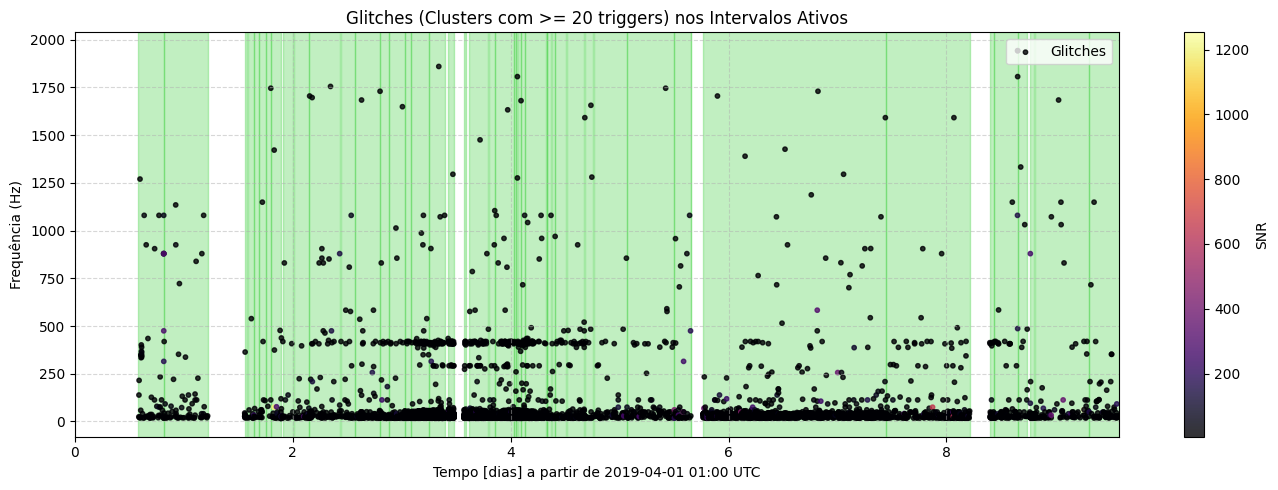

In [146]:
import matplotlib.pyplot as plt

# 1. Filtra os dois DataFrames para a janela de tempo [start, end]
intervals_crop = intervals[(intervals['int2'] >= start) & (intervals['int1'] <= end)]
glitches_crop = df_glitches_final[(df_glitches_final['time'] >= start) & 
                                  (df_glitches_final['time'] <= end)]

# 2. Converte os tempos para "dias a partir de 'start'"
intervals_start_days = (intervals_crop['int1'] - start) / 86400
intervals_end_days = (intervals_crop['int2'] - start) / 86400
glitches_days = (glitches_crop['time'] - start) / 86400

# 3. Cria a figura
plt.figure(figsize=(14, 5))

# Plota os intervalos de funcionamento em verde ao fundo
for s, e in zip(intervals_start_days, intervals_end_days):
    plt.axvspan(s, e, color='limegreen', alpha=0.3)

# Plota os Glitches
# Dica: 's' define o tamanho do ponto baseado no SNR ou número de triggers
scatter = plt.scatter(
    glitches_days, 
    glitches_crop['frequency'], 
    c=glitches_crop['snr'],        # Cor do ponto baseada na SNR do glitch
    cmap='inferno',                # Escala de cor
    s=10,                          # Tamanho do marcador
    alpha=0.8, 
    label='Glitches'
)

# Adiciona barra de cores para a SNR
cbar = plt.colorbar(scatter)
cbar.set_label('SNR')

# Ajustes de layout
plt.xlabel(f'Tempo [dias] a partir de {date_start} UTC')
plt.ylabel('Frequência (Hz)')
plt.title('Glitches (Clusters com >= 20 triggers) nos Intervalos Ativos')
plt.xlim(0, (end - start) / 86400)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [147]:
df_abril = pd.DataFrame({
    'triggers' : triggers_quantity,
    'glitches' : glithes_quantity
})

In [148]:
df_abril

,triggers,glitches
0,212320,87
1,172113,145
2,267901,346
3,929860,4381
4,491367,1992
5,414648,284
6,352671,896
7,319335,543
8,272764,420
9,424506,245


In [149]:
print(df_abril)
print(f"\ntotal triggers: {df_abril['triggers'].sum()}\ntotal glitches: {df_abril['glitches'].sum()}")

   triggers  glitches
0    212320        87
1    172113       145
2    267901       346
3    929860      4381
4    491367      1992
5    414648       284
6    352671       896
7    319335       543
8    272764       420
9    424506       245

total triggers: 3857485
total glitches: 9339


# Compare with gspy clustering

In [25]:
path = os.getcwd()
path

'/home/esanches/Projetos/tSNE/Virgo'

In [30]:
intervals

,int1,int2,duration
0,1.238166e+09,1238186420,20402
1,1.238186e+09,1238220967,34539
2,1.238250e+09,1238252421,2143
3,1.238253e+09,1238257817,5220
4,1.238258e+09,1238261506,3535
...,...,...,...
1345,1.253831e+09,1253863588,32968
1346,1.253866e+09,1253872893,6843
1347,1.253909e+09,1253915996,6720
1348,1.253916e+09,1253941833,25831


In [32]:
df_gspy = pd.read_csv(path + '/gspyO3a.csv')

df_gspy = df_gspy.sort_values("GPStime").reset_index(drop=True)
intervals = intervals.sort_values("int1").reset_index(drop=True)

merged = pd.merge_asof(
    df_gspy,
    intervals,
    left_on="GPStime",
    right_on="int1",
    direction="backward"
)

df_gspy_filtrado = merged[merged["GPStime"] <= merged["int2"]].copy()
df_gspy_filtrado = df_gspy_filtrado.drop(columns=["int1", "int2", "duration"], errors='ignore')

print(f"Total original: {len(df_gspy)} glitches")
print(f"Glitches em intervalos ativos: {len(df_gspy_filtrado)} glitches")

Total original: 80398 glitches
Glitches em intervalos ativos: 79436 glitches


In [34]:
run_start_day_O3a = datetime(2019, 4, 1, 0, 0, 0)
run_end_day_test  = datetime(2019, 4, 10, 0, 0, 0)

# 2. Converte datetime para GPS time
gps_start_test = Time(run_start_day_O3a, scale="utc").gps
gps_end_test   = Time(run_end_day_test, scale="utc").gps

In [35]:
df_gspy_corte = df_gspy_filtrado[(df_gspy_filtrado['GPStime'] >= gps_start_test) & (df_gspy_filtrado['GPStime'] <= gps_end_test)].copy()

In [36]:
df_gspy_corte

,GPStime,peakFreq,snr,amplitude,centralFreq,duration_x,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value,duration_y
0,1.238166e+09,118.526,12.088,1.090000e-22,211.877,0.094,331.946350,0.0,0.0,1.000,U9hF0CFicL,V1,Blip,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657,20402
1,1.238167e+09,19.950,7.867,2.590000e-21,20.195,0.750,8.390090,0.0,0.0,0.998,cFEXeEnnvv,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627,20402
2,1.238167e+09,41.312,8.180,2.460000e-22,65.530,0.078,82.279373,0.0,0.0,1.000,7Rmzlmneu5,V1,Blip,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657,20402
3,1.238167e+09,19.056,8.306,3.290000e-21,19.370,1.750,2.439150,0.0,0.0,0.965,pwXEfq8DlK,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,20402
4,1.238168e+09,340.202,12.113,1.970000e-22,357.194,0.313,218.644699,0.0,0.0,1.000,wiP1dmnUtc,V1,Whistle,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,20402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8220,1.238883e+09,19.292,8.259,2.230000e-21,2721.614,1.500,5407.210449,0.0,0.0,1.000,9UHb4Ldzvm,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,42499
8221,1.238883e+09,19.240,8.160,2.220000e-21,19.299,1.250,2.581050,0.0,0.0,1.000,ErDGS996wL,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627,42499
8222,1.238884e+09,95.999,277.984,2.610000e-21,3983.241,3.855,7934.482910,0.0,0.0,0.754,HaZgUk3Q10,V1,Koi_Fish,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657,42499
8223,1.238884e+09,19.896,8.963,1.850000e-21,20.195,1.500,8.390090,0.0,0.0,0.959,WEHMtGv2dr,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,42499


In [ ]:
# ---------------- Loop principal ----------------
while current_day <= run_end_day:
    day_start = datetime(current_day.year, current_day.month, current_day.day, 0, 0, 0)
    day_end   = datetime(current_day.year, current_day.month, current_day.day, 23, 59, 59)
    print(f"Processando dia: {current_day.date()}")

    # --- tempo ativo ---
    try:
        total_active_seconds, DQ = dq_active_seconds(chDQ, state_val, day_start, day_end)
    except Exception as e:
        print(f"  Falha ao obter DQ ({current_day.date()}): {e}")
        total_active_seconds = 0.0
    total_active_hours = total_active_seconds / 3600.0

    # --- triggers ---
    gps_start = Time(day_start, scale="utc").gps
    gps_end = Time(day_end, scale="utc").gps
    trigfiles = find_trigger_files(ch, gps_start, gps_end)
    
    if len(trigfiles) == 0:
        print(f"Nenhum arquivo encontrado para o dia {day_start.date()}")
        gltab = pd.DataFrame()
    else:
        # 1. Abre o arquivo ROOT e carrega a árvore 'triggers' para um DataFrame
        with uproot.open(trigfiles[0]) as file:
            gltab = file["triggers"].arrays(library="pd")
    
        # 2. Ordena por tempo (se a tabela não estiver vazia)
        if not gltab.empty:
            gltab = gltab.sort_values(by="time").reset_index(drop=True)
    
            # 3. Substituição do at_unique: remove gatilhos duplicados baseados no tempo
            gltab = gltab.drop_duplicates(subset=["time"]).reset_index(drop=True)
    
    print(f"{gltab}\n\n")
    
    # --- clusterização ---
    if not gltab.empty:
        clustered = clusterize_triggers(gltab, window=cluster_window)
    else:
        clustered = pd.DataFrame()

    # --- counts pós SNR cut ---
    counts_nonclustered = {snr: int(np.sum(gltab['snr'] > snr)) if len(gltab) > 0 else 0 for snr in snr_thresholds}
    counts_clustered   = {snr: int(np.sum(clustered['snr'] > snr)) if len(clustered) > 0 else 0 for snr in snr_thresholds}

    monthly_results.append({
        "date": current_day.date(),
        "n_triggers_nonclustered": int(len(gltab)),
        "n_triggers_clustered": int(len(clustered)),
        "counts_nonclustered": counts_nonclustered,
        "counts_clustered": counts_clustered,
        "total_active_seconds": total_active_seconds
    })

    # --- salvar parcial ---
    if len(monthly_results) % days_per_part == 0:
        fname = f"O4b_part{part_number}.npy"
        np.save(fname, monthly_results)
        print(f"=== Resultados parciais salvos em {fname} ===\n")
        part_number += 1
        monthly_results = []

    current_day += timedelta(days=1)

In [4]:
def find_trigger_files(ch, start, end, trigpath="/data/*/omicron/", ext="root"):

    
    allfiles = glob.glob(os.path.join(trigpath, "{}/{}_OMICRON".format(*ch.split(":")), "**", f"*.{ext}"), recursive=True)
    if not allfiles:
        print(f"Nenhum arquivo encontrado no caminho {trigpath}")
        return []
    allstart, alldur = np.array([f.rstrip(f".{ext}").split("-")[-2:] for f in allfiles]).astype(int).T
    try:
        rightfiles = np.asarray(allfiles)[(allstart + alldur > start) & (end > allstart)]
    except TypeError:
        print(f"Nenhum arquivo relevante encontrado entre {start} e {end}")
        return []
    return rightfiles

In [5]:
find_trigger_files

<function __main__.find_trigger_files(ch, start, end, trigpath='/data/*/omicron/', ext='root')>

In [6]:
def clusterize_triggers(table, window=0.1):
    if len(table) == 0:
        return EventTable(rows=[])  # retorna tabela vazia se não houver triggers

    table = table.copy()
    table.sort('tstart')

    cluster_ids = np.zeros(len(table), dtype=int)
    cluster_index = 0
    for i in range(1, len(table)):
        delta_t = table[i]['tstart'] - table[i-1]['tend']
        if delta_t <= window:
            cluster_ids[i] = cluster_index
        else:
            cluster_index += 1
            cluster_ids[i] = cluster_index

    table['cluster'] = cluster_ids
    summary_rows = []
    for cl in np.unique(cluster_ids):
        cluster_rows = table[table['cluster'] == cl]
        if len(cluster_rows) == 0:
            continue
        max_idx = np.argmax(cluster_rows['snr'])
        max_row = cluster_rows[max_idx]

        summary_rows.append({
            'cluster': cl,
            'tstart': np.min(cluster_rows['tstart']),
            'tend': np.max(cluster_rows['tend']),
            'fmin': np.min(cluster_rows['fstart']),
            'fmax': np.max(cluster_rows['fend']),
            'time': max_row['time'],
            'frequency': max_row['frequency'],
            'q': max_row['q'],
            'snr': max_row['snr'],
            'phase': max_row['phase']
        })
    return EventTable(rows=summary_rows)

In [7]:
ch = "V1:Hrec_hoft_16384Hz"
chDQ = "V1:META_ITF_LOCK_index"
state_val = 135  # low-noise

#Janela de operação
run_start_day = datetime(2024, 5, 10, 0, 0, 0)
run_end_day   = datetime(2024, 5, 20, 23, 59, 59)

snr_thresholds = [6.5, 10] #SNR_cut
cluster_window = 0.1  # Janela de clusterização (segundos)

days_per_part = 20
part_number = 1
current_day = run_start_day
monthly_results = []

In [12]:
# ---------------- Loop principal ----------------
while current_day <= run_end_day:
    day_start = datetime(current_day.year, current_day.month, current_day.day, 0, 0, 0)
    day_end   = datetime(current_day.year, current_day.month, current_day.day, 23, 59, 59)
    print(f"Processando dia: {current_day.date()}")

    # --- tempo ativo ---
    try:
        total_active_seconds, DQ = dq_active_seconds(chDQ, state_val, day_start, day_end)
    except Exception as e:
        print(f"  Falha ao obter DQ ({current_day.date()}): {e}")
        total_active_seconds = 0.0
    total_active_hours = total_active_seconds / 3600.0

    # --- triggers ---
    gps_start = Time(day_start, scale="utc").gps
    gps_end = Time(day_end, scale="utc").gps
    trigfiles = find_trigger_files(ch, gps_start, gps_end)
    
    if len(trigfiles) == 0:
        print(f"Nenhum arquivo encontrado para o dia {day_start.date()}")
        gltab = pd.DataFrame()
    else:
        # 1. Abre o arquivo ROOT e carrega a árvore 'triggers' para um DataFrame
        with uproot.open(trigfiles[0]) as file:
            gltab = file["triggers"].arrays(library="pd")
    
        # 2. Ordena por tempo (se a tabela não estiver vazia)
        if not gltab.empty:
            gltab = gltab.sort_values(by="time").reset_index(drop=True)
    
            # 3. Substituição do at_unique: remove gatilhos duplicados baseados no tempo
            gltab = gltab.drop_duplicates(subset=["time"]).reset_index(drop=True)
    
    print(f"{gltab}\n\n")
    
    # --- clusterização ---
    if not gltab.empty:
        clustered = clusterize_triggers(gltab, window=cluster_window)
    else:
        clustered = pd.DataFrame()

    # --- counts pós SNR cut ---
    counts_nonclustered = {snr: int(np.sum(gltab['snr'] > snr)) if len(gltab) > 0 else 0 for snr in snr_thresholds}
    counts_clustered   = {snr: int(np.sum(clustered['snr'] > snr)) if len(clustered) > 0 else 0 for snr in snr_thresholds}

    monthly_results.append({
        "date": current_day.date(),
        "n_triggers_nonclustered": int(len(gltab)),
        "n_triggers_clustered": int(len(clustered)),
        "counts_nonclustered": counts_nonclustered,
        "counts_clustered": counts_clustered,
        "total_active_seconds": total_active_seconds
    })

    # --- salvar parcial ---
    if len(monthly_results) % days_per_part == 0:
        fname = f"O4b_part{part_number}.npy"
        np.save(fname, monthly_results)
        print(f"=== Resultados parciais salvos em {fname} ===\n")
        part_number += 1
        monthly_results = []

    current_day += timedelta(days=1)

Processando dia: 2024-05-10
  Falha ao obter DQ (2024-05-10): name 'dq_active_seconds' is not defined
Nenhum arquivo encontrado no caminho /data/*/omicron/
Nenhum arquivo encontrado para o dia 2024-05-10
Empty DataFrame
Columns: []
Index: []


Processando dia: 2024-05-11
  Falha ao obter DQ (2024-05-11): name 'dq_active_seconds' is not defined
Nenhum arquivo encontrado no caminho /data/*/omicron/
Nenhum arquivo encontrado para o dia 2024-05-11
Empty DataFrame
Columns: []
Index: []


Processando dia: 2024-05-12
  Falha ao obter DQ (2024-05-12): name 'dq_active_seconds' is not defined
Nenhum arquivo encontrado no caminho /data/*/omicron/
Nenhum arquivo encontrado para o dia 2024-05-12
Empty DataFrame
Columns: []
Index: []


Processando dia: 2024-05-13
  Falha ao obter DQ (2024-05-13): name 'dq_active_seconds' is not defined
Nenhum arquivo encontrado no caminho /data/*/omicron/
Nenhum arquivo encontrado para o dia 2024-05-13
Empty DataFrame
Columns: []
Index: []


Processando dia: 2024-05

In [ ]:
# --- salvar última parte ---
if len(monthly_results) > 0:
    fname = f"O4b_part{part_number}.npy"
    np.save(fname, monthly_results)
    print(f"=== Última parte salva em {fname} ===\n")

# ---------------- Combinar todas as partes em CSV final ----------------
all_parts = []
part_number = 1
while True:
    fname = f"O4b_part{part_number}.npy"
    if not os.path.exists(fname):
        break
    arr = np.load(fname, allow_pickle=True)
    all_parts.extend(arr)
    part_number += 1

# converter para DataFrame
df = pd.DataFrame(all_parts)

# remover linhas com counts zero
def nonzero_counts(row):
    nc = row.get('counts_nonclustered', {}) if isinstance(row.get('counts_nonclustered', {}), dict) else {}
    c  = row.get('counts_clustered', {}) if isinstance(row.get('counts_clustered', {}), dict) else {}
    return any(v > 0 for v in nc.values()) or any(v > 0 for v in c.values())

df = df[df.apply(nonzero_counts, axis=1)]

# salvar CSV final
df.to_csv("O4b_full.csv", index=False)
print("Arquivo final salvo: O4b_full.csv")